
<font size = "5"> **Day 3: [Spectroscopic Data & ML‑Enabled Analysis](../MLSTEM2026.ipynb)** </font>


<hr style="height:1px;border-top:4px solid #FF8200" />



[Download](https://github.com/gduscher/MLSTEM2026/raw/refs/heads/main/Day3/10AM_Acquire_EDS_Spectra.ipynb)

[![OpenInColab](https://colab.research.google.com/assets/colab-badge.svg)](
   https://colab.research.google.com/github/gduscher/MLSTEM2026/blob/main/Day3/10AM_Acquire_EDS_Spectra.ipynb)


# Acquire Image and EDS Point Spectra

part of the workshop of 

<font size = "5"> **[Machine Learning in Transmission Electron Microscopy](../MLSTEM2026.ipynb)**</font>


**Day3: Spectroscopic Data & ML‑Enabled Analysis**
<table style="margin-right:auto;margin-left:0px">
  <tr>
    <td>Gerd Duscher </td>
    <td>Sergei Kalinin</td>
  </tr>
  <tr>
    <td colspan="2"><center>Microscopy Facilities</td> 
  </tr>
  
  <tr>
    <td colspan="2"><center>Materials Science & Engineering</td>
    <td></td>
  </tr>
  <tr>
    <td colspan="2"><center>Institute of Advanced Materials & Manufacturing</td>
  </tr>
  <tr>
    <td colspan="2"><center> The University of Tennessee, Knoxville</center> </td>
  </tr>
</table>
        
**June 2026**

Main Contributer to Notebook: Levi Dunn, Dominick Patela, Austin Houston


## Overview
Acquire an image and collect EDS spectra at selected beam positions.

## Import packages for figures and 
First we load the code to make figures from pyTEMlib
### Check Installed Packages






### Run the servers

Make sure you are on the VPN and the pyTango server is running on the microscope. 

```bash
uv run startup_scripts/run_servers.py
```


### Imports


In [ ]:
%matplotlib widget
import os
import json

import matplotlib.pylab as plt
import numpy  as np

import tango
import tiled.client
import pyTEMlib

print('pyTEMlib version: ', pyTEMlib.__version__)

pyTEMlib version:  0.2026.6.0


### Ping servers


In [ ]:
DB_HOST = "10.46.217.241"
DB_PORT = 9094

os.environ["TANGO_HOST"] = f"{DB_HOST}:{DB_PORT}"

server_names = ['stage', 'scan', 'eds', 'camera', 'data', 'microscope']

scan = tango.DeviceProxy("asyncroscopy/scan/default")
microscope = tango.DeviceProxy("asyncroscopy/instrument/default")
data = tango.DeviceProxy("asyncroscopy/data/default")

for proxy in [scan, microscope, data]:
    proxy.set_timeout_millis(120_000)
    proxy.ping()
    print(proxy.name(), proxy.state())

asyncroscopy/scan/default ON
asyncroscopy/instrument/default ON
asyncroscopy/data/default ON


### Set Tiled Client


In [ ]:
config = json.loads(data.get_config())

client = tiled.client.from_uri(config.get("uri"))
print("Tiled keys:", list(client))
config

Tiled keys: ['camera_image_BM-Ceta_20260618T094427441181.h5', 'stem_image_HAADF_20260618T084144976547.h5', 'stem_image_HAADF_20260618T094405056522.h5', 'stem_image_HAADF_20260618T094431919648.h5', 'stem_image_HAADF_20260618T094635890432.h5', 'stem_image_HAADF_20260618T094716186691.h5', 'stem_image_HAADF_20260619T095615913198.h5', 'stem_image_HAADF_20260619T095628564088.h5', 'stem_image_HAADF_20260619T095746361980.h5', 'stem_image_HAADF_20260619T095815519708.h5', 'stem_image_HAADF_20260619T134153090221.h5', 'stem_image_HAADF_20260619T134352853543.h5', 'stem_image_HAADF_20260619T134402685036.h5', 'stem_image_HAADF_20260619T134423325285.h5', 'stem_image_HAADF_20260619T134505467705.h5', 'stem_image_HAADF_20260619T135332036391.h5', 'stem_image_HAADF_20260619T135354973665.h5', 'stem_image_HAADF_20260619T135456889785.h5', 'camera_image_BM-Ceta_20260619T172037535259.h5', 'stem_image_HAADF_20260620T062929584794.h5', 'stem_image_HAADF_20260620T063004613243.h5', 'stem_image_HAADF_20260620T0630195

{'host': '10.46.217.241',
 'port': 9091,
 'uri': 'http://10.46.217.241:9091',
 'save_path': 'outputs/tiled_acquisitions',
 'tiled_server': 'yes',
 'tiled_server_status': 'running; serving path; files register manually',
 'tiled_server_serving': 'outputs/tiled_acquisitions'}

### Acquire a reference image


In [ ]:
scan.dwell_time = 1e-6
scan.imsize = 512
scan.scan_region = [0, 0, 1, 1]

print("dwell_time :", scan.dwell_time)
print("image size :", scan.imsize)
print("scan region:", list(scan.scan_region))


dwell_time : 1e-06
image size : 512
scan region: [np.float64(0.0), np.float64(0.0), np.float64(1.0), np.float64(1.0)]


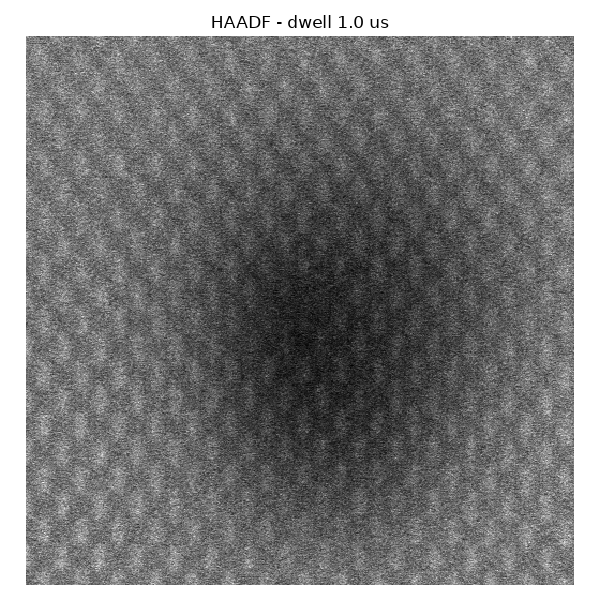

In [ ]:
data_key = microscope.acquire_scanned_image(["haadf"])

image = client[data_key]["image"]["HAADF"].read()
metadata = dict(client[data_key]["image"]["HAADF"].metadata)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(image, cmap="gray", interpolation="none")
ax.set_title(f"HAADF - dwell {scan.dwell_time * 1e6:.1f} us")
ax.axis("off")
plt.tight_layout()

### Choose random beam positions


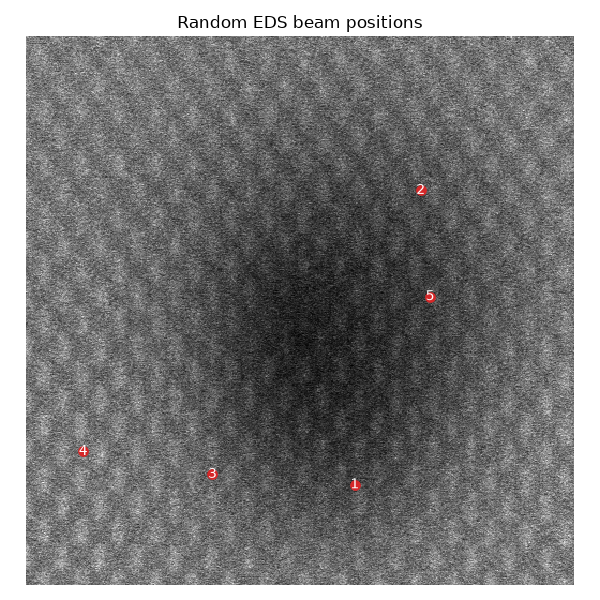

In [8]:
rng = np.random.default_rng(7)
n_points = 5
beam_points = rng.uniform(0.1, 0.9, size=(n_points, 2))

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(image, cmap="gray", interpolation="none")
height, width = image.shape
ax.scatter(beam_points[:, 0] * (width - 1), beam_points[:, 1] * (height - 1), c="tab:red", s=45)
for index, (x_frac, y_frac) in enumerate(beam_points, start=1):
    ax.text(x_frac * (width - 1), y_frac * (height - 1), str(index), color="white", ha="center", va="center")
ax.set_title("Random EDS beam positions")
ax.axis("off")
plt.tight_layout()


### Place the beam and collect EDS spectra


In [9]:
spectra = []

for index, point in enumerate(beam_points, start=1):
    microscope.place_beam(point.tolist())
    key = microscope.acquire_spectrum("eds")
    node = client[key]["spectrum"]
    spectrum = np.squeeze(np.asarray(node.read()))
    metadata = dict(node.metadata)
    spectra.append({
        "point_index": index,
        "beam_position": point.tolist(),
        "tiled_key": key,
        "metadata": metadata,
        "spectrum": spectrum,
    })
    print(f"Point {index}: key={key}, beam={point.tolist()}, bins={spectrum.size}")


Point 1: key=spectrum_eds_20260620T161020490471.h5, beam=[0.6000763732837335, 0.8177710407756604], bins=4096
Point 2: key=spectrum_eds_20260620T161023303243.h5, beam=[0.7205485521961549, 0.2801657519924735], bins=4096
Point 3: key=spectrum_eds_20260620T161025670551.h5, beam=[0.34013302792898037, 0.7988427563170095], bins=4096
Point 4: key=spectrum_eds_20260620T161028033836.h5, beam=[0.10421224365245979, 0.756982734706213], bins=4096
Point 5: key=spectrum_eds_20260620T161030458287.h5, beam=[0.737655543001637, 0.47434796227497666], bins=4096


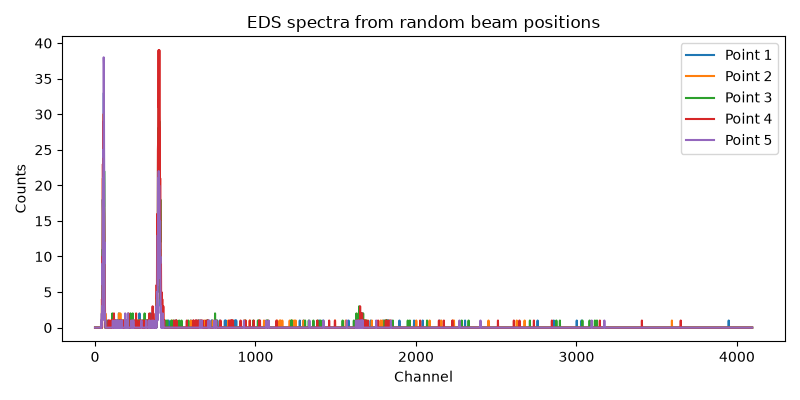

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
for record in spectra:
    ax.plot(record["spectrum"], label=f"Point {record['point_index']}")
ax.set_xlabel("Channel")
ax.set_ylabel("Counts")
ax.set_title("EDS spectra from random beam positions")
ax.legend()
plt.tight_layout()


### Configure and acquire an EDS spectrum


In [ ]:
eds_proxy = tango.DeviceProxy("asyncroscopy/eds/default")
eds_proxy.exposure_time = 30  # in seconds

In [18]:
key = microscope.acquire_spectrum("eds")
node = client[key]["spectrum"]
spectrum = np.squeeze(np.asarray(node.read()))
metadata = dict(node.metadata)

print("Tiled key     :", key)
print("Metadata      :", metadata)
print("Spectrum shape:", spectrum.shape)
print("Spectrum dtype:", spectrum.dtype)


Tiled key     : spectrum_eds_20260620T161304283593.h5
Metadata      : {'AccelerationVoltage': '200000', 'AcquisitionDatetime': '2026-06-20T20:13:04Z', 'AcquisitionStartDatetime': '2026-06-20T20:12:31Z', 'Alpha': '-0.136045177', 'ApplicationSoftware': 'AutoScript TEM', 'ApplicationSoftwareVersion': '1.15.0.484', 'AzimuthAngle': '0.785398163', 'AzimuthAngle_150': '2.35619449', 'AzimuthAngle_166': '3.92699082', 'AzimuthAngle_182': '5.49778714', 'BeamConvergence': '0.0300277414', 'BeamDiameter': '0', 'Begin': '0', 'Begin_119': '0', 'Begin_127': '0.0728785469', 'Beta': '-0.106560491', 'C1LensIntensity': '-0.451997309', 'C2LensIntensity': '0.19413309', 'C3LensIntensity': '0.354081585', 'CameraLength': '0.091', 'CollectionAngle': '0.7', 'CollectionAngle_151': '0.7', 'CollectionAngle_167': '0.7', 'CollectionAngle_183': '0.7', 'ComputerName': 'TITAN52340180', 'ControlSoftwareVersion': '3.21.1', 'DarkGainCorrectionType': 'DarkGain', 'DarkGainCorrectionType_212': 'DarkGain', 'DarkGainCorrectionTy

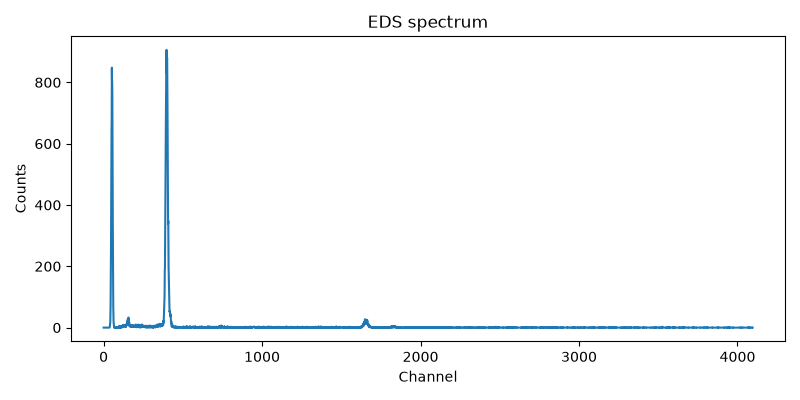

In [19]:
plt.figure(figsize=(8, 4))
plt.plot(spectrum)
plt.xlabel("Channel")
plt.ylabel("Counts")
plt.title("EDS spectrum")
plt.tight_layout()

In [14]:
metadata

{'AccelerationVoltage': '200000',
 'AcquisitionDatetime': '2026-06-20T20:11:34Z',
 'AcquisitionStartDatetime': '2026-06-20T20:11:32Z',
 'Alpha': '-0.136045177',
 'ApplicationSoftware': 'AutoScript TEM',
 'ApplicationSoftwareVersion': '1.15.0.484',
 'AzimuthAngle': '0.785398163',
 'AzimuthAngle_140': '2.35619449',
 'AzimuthAngle_156': '3.92699082',
 'AzimuthAngle_172': '5.49778714',
 'BeamConvergence': '0.0300277414',
 'BeamDiameter': '0',
 'Begin': '0',
 'Begin_109': '0',
 'Begin_117': '0.0728785469',
 'Beta': '-0.106560491',
 'C1LensIntensity': '-0.451997309',
 'C2LensIntensity': '0.19413309',
 'C3LensIntensity': '0.354081585',
 'CameraLength': '0.091',
 'CollectionAngle': '0.7',
 'CollectionAngle_141': '0.7',
 'CollectionAngle_157': '0.7',
 'CollectionAngle_173': '0.7',
 'ComputerName': 'TITAN52340180',
 'ControlSoftwareVersion': '3.21.1',
 'DarkGainCorrectionType': 'DarkGain',
 'DarkGainCorrectionType_202': 'DarkGain',
 'DarkGainCorrectionType_213': 'DarkGain',
 'Defocus': '1.472697